In [65]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [66]:
T = 0.5
N = 100
M = 500

In [67]:
tv = np.linspace(0,T,N+1)
W = np.zeros(shape=(M,N+1))
for t in range(1,N+1):
    deltat = tv[t]-tv[t-1]
    W[:,t] = W[:,t-1]+np.sqrt(deltat)*np.random.normal(0,1,size=M)

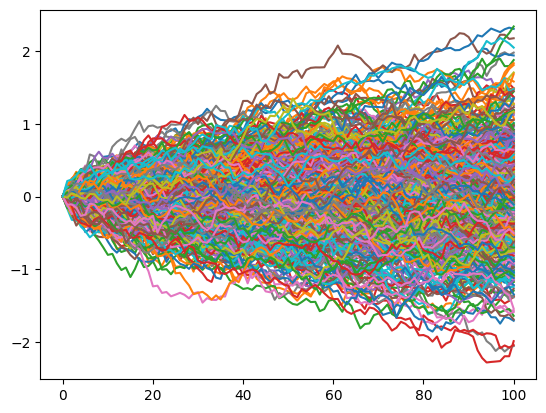

In [68]:
plt.plot(W[0:500,:].T)
plt.show()

In [113]:
sv = np.linspace(0.1,1,M)*10+abs(np.random.normal())
X = np.zeros(shape=(M,N+1))
for i in range(M):
    X[i,:] = sv[i]*W[i,:]

dX = X[:,1:]-X[:,0:-1]

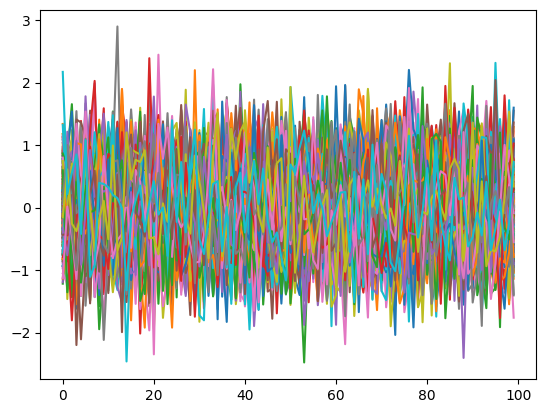

In [114]:
plt.plot(dX[0:500,:].T)
plt.show()

In [115]:
Phi = torch.nn.Sequential(
    torch.nn.Linear(N,16),
    torch.nn.ReLU(),
    torch.nn.Linear(16,16),
    torch.nn.ReLU(),
    torch.nn.Linear(16,16),
    torch.nn.ReLU(),
    torch.nn.Linear(16,1)
)

In [116]:
sv_t = torch.Tensor(sv)
dX_t = torch.Tensor(dX)
epochs = 100
eta = 1e-3

In [117]:
loss = torch.nn.MSELoss()
opt = torch.optim.SGD(lr=eta,params=Phi.parameters())
bs = 12

In [118]:
for e in range(1,epochs+1):
    order = torch.randperm(M)
    L_c = 0
    for b in range(0,M,bs):
        L = 0

        opt.zero_grad()
        for i in order[b:b+bs]:
            L += loss(sv_t[i],Phi(dX_t[i,:]))
        L = L/len(order[b:b+bs])
        L.backward()  
        opt.step()
        L_c += L.item()

    if e % 5==0:
        print(f"{e}:{L_c}")

C:\Users\trist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


5:247.64690732955933
10:193.52558648586273
15:139.907408118248
20:90.50610339641571
25:54.07826992869377
30:32.5786757171154
35:20.475691616535187
40:14.022494122385979
45:10.356486570090055
50:7.975684583187103
55:6.37112563662231
60:5.209574688225985
65:4.383967595174909
70:3.6915521696209908
75:3.1522825211286545
80:2.733942748978734
85:2.3946348102763295
90:2.1277296161279082
95:1.8950086385011673
100:1.6921672159805894


In [112]:
print(Phi(dX_t[0,:]).detach())
print(sv[0])

tensor([1.7180])
1.0
